In [1]:
# --- 1. Imports & Setup ---
import os
import sys
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import h5py
import importlib

# AllenSDK
from allensdk.brain_observatory.ecephys.ecephys_project_cache import EcephysProjectCache

# Analysis & TDA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import umap
from ripser import ripser
from persim import plot_diagrams

# Visualization
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import networkx as nx

# Add lib folder to path for viz_style
sys.path.append(os.path.abspath("lib"))

# Custom Style
import viz_style
importlib.reload(viz_style) # Reload to ensure latest changes are applied
viz_style.set_architectural_style()

print("Libraries imported and Architectural Style applied.")

Architectural plot style applied (Dark Mode).
Libraries imported and Architectural Style applied.


In [2]:
# --- 2. Data Loading & Preprocessing ---
# Load Data
output_dir = "../Dataset/RAW"
manifest_path = os.path.join(output_dir, "manifest.json")
cache = EcephysProjectCache.from_warehouse(manifest=manifest_path)

session_id = 750749662
print(f"Loading Session {session_id}...")
session = cache.get_session_data(session_id)

# Filter for CA1 Units
region_acronym = "CA1"
region_units = session.units[session.units["ecephys_structure_acronym"] == region_acronym]
print(f"Selected {len(region_units)} units from {region_acronym}")

# Construct Neural Response Matrix (Natural Movie One)
movie_table = session.get_stimulus_table("natural_movie_one")
frame_duration = movie_table['duration'].mean()

print("Calculating spike counts (Frames x Neurons)...")
spike_counts_xr = session.presentationwise_spike_counts(
    stimulus_presentation_ids=movie_table.index.values,
    bin_edges=np.array([0, frame_duration]),
    unit_ids=region_units.index.values
)

# Sum spikes within each frame window
response_matrix_all = spike_counts_xr.sum(dim="time_relative_to_stimulus_onset")

# Create DataFrame
df_response = pd.DataFrame(
    response_matrix_all.values,
    index=movie_table.index,
    columns=region_units.index
)
df_response['frame'] = movie_table['frame']

# Average across repeats (if any) - Natural Movie One is usually repeated
average_response_matrix = df_response.groupby('frame').mean()

# Final Matrix: X (Frames x Neurons)
X = average_response_matrix.values
print(f"Final Neural Response Matrix Shape: {X.shape}")

Loading Session 750749662...


Downloading:   0%|          | 0.00/2.82G [00:00<?, ?B/s]

c:\Users\jord9\anaconda3\envs\NeuralTDA\Lib\site-packages\hdmf\spec\namespace.py:590: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.2.2, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)
c:\Users\jord9\anaconda3\envs\NeuralTDA\Lib\site-packages\hdmf\spec\namespace.py:590: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.2.2, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)
c:\Users\jord9\anaconda3\envs\NeuralTDA\Li

Selected 113 units from CA1


c:\Users\jord9\anaconda3\envs\NeuralTDA\Lib\site-packages\hdmf\spec\namespace.py:590: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.2.2, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


Calculating spike counts (Frames x Neurons)...
Final Neural Response Matrix Shape: (900, 113)


In [3]:
# Load Movie Template for Visualization
print("Loading Natural Movie One Template...")
movie_template = cache.get_natural_movie_template(1)
print(f"Movie Template Shape: {movie_template.shape}")

Loading Natural Movie One Template...
Movie Template Shape: (900, 304, 608)


PCA Reduced Shape: (900, 50)
Running UMAP (3D)...


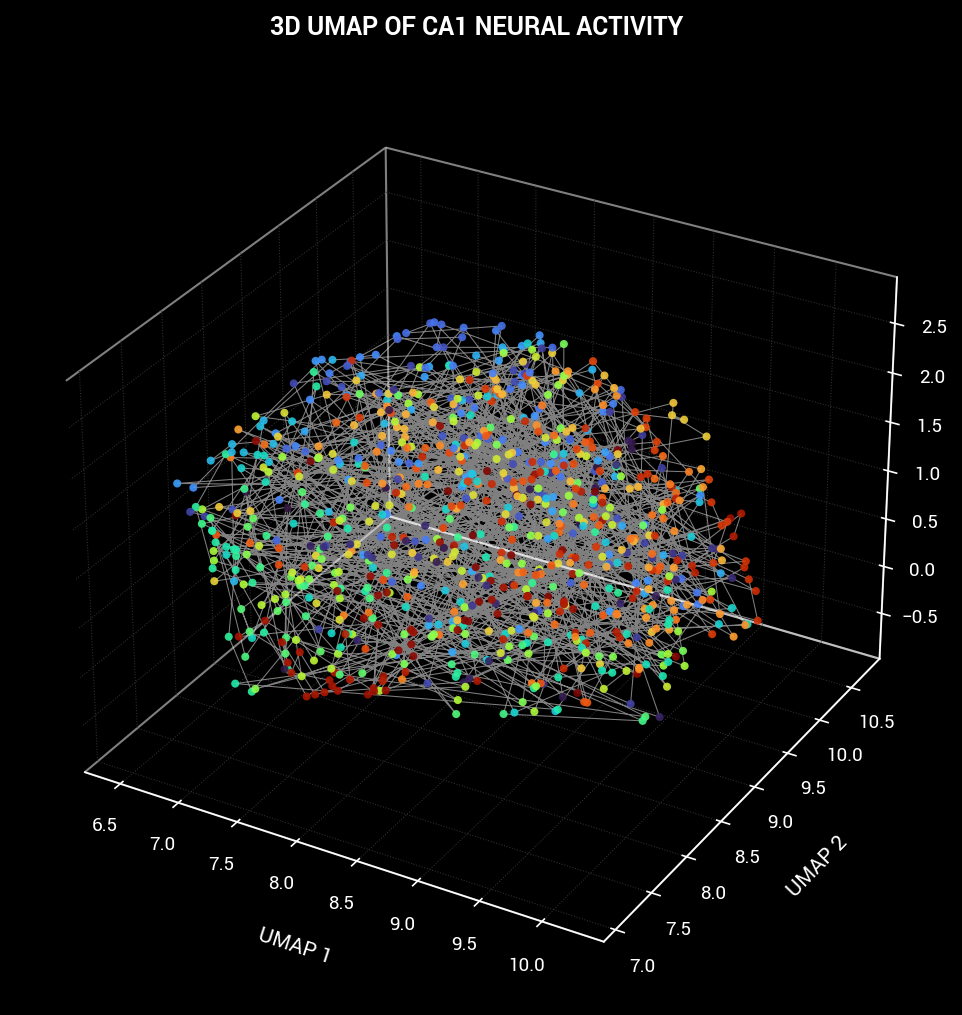

In [4]:
# --- 3. PCA & UMAP ---
# PCA (Linear Reduction)
n_components_pca = 50
pca = PCA(n_components=n_components_pca)
X_pca = pca.fit_transform(StandardScaler().fit_transform(X))
print(f"PCA Reduced Shape: {X_pca.shape}")

# UMAP (Non-linear Visualization)
print("Running UMAP (3D)...")
reducer = umap.UMAP(n_components=3, n_neighbors=15, min_dist=0.1, random_state=42)
embedding_3d = reducer.fit_transform(X_pca)

# Visualize 3D UMAP (Architectural Style)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

viz_style.plot_3d_trajectory(
    ax,
    embedding_3d[:, 0], embedding_3d[:, 1], embedding_3d[:, 2],
    c=np.arange(len(embedding_3d)), # Color by time (frame index)
    cmap='turbo',
    title=f"3D UMAP OF {region_acronym} NEURAL ACTIVITY",
    xlabel="UMAP 1", ylabel="UMAP 2", zlabel="UMAP 3"
)
plt.show()

Running Ripser on 900 points...


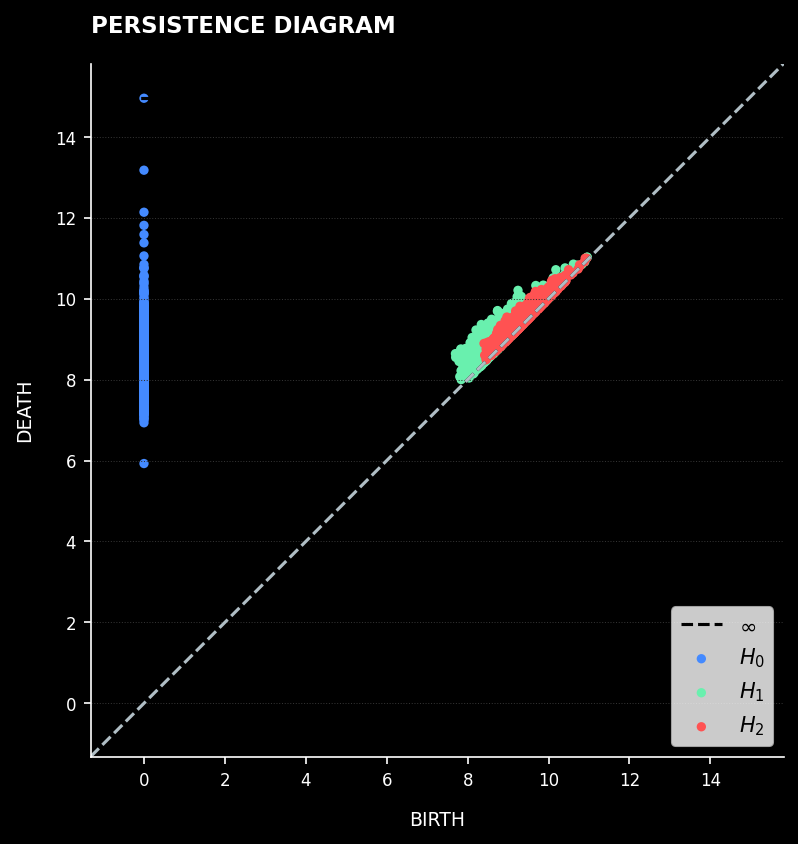

Interpretation:
- H0 (Blue): Connected components. Long bars = distinct clusters.
- H1 (Orange): Loops/Cycles. Long bars = significant loops.
- H2 (Green): Voids. Long bars = significant 3D voids.


In [5]:
# --- 4. Topological Data Analysis (Ripser) ---
# Calculate H0 (Clusters), H1 (Loops), H2 (Voids)
X_tda = X_pca # Use full data

print(f"Running Ripser on {X_tda.shape[0]} points...")
result = ripser(X_tda, maxdim=2)
diagrams = result['dgms']

# Plot Persistence Diagrams
fig, ax = plt.subplots(figsize=(6, 6))
plot_diagrams(diagrams, show=False, ax=ax)
viz_style.format_axis(ax, title="Persistence Diagram", xlabel="Birth", ylabel="Death")
# Force diagonal line color
ax.plot([0, 1], [0, 1], transform=ax.transAxes, color=viz_style.GRAY, linestyle="--")
plt.show()

print("Interpretation:")
print("- H0 (Blue): Connected components. Long bars = distinct clusters.")
print("- H1 (Orange): Loops/Cycles. Long bars = significant loops.")
print("- H2 (Green): Voids. Long bars = significant 3D voids.")

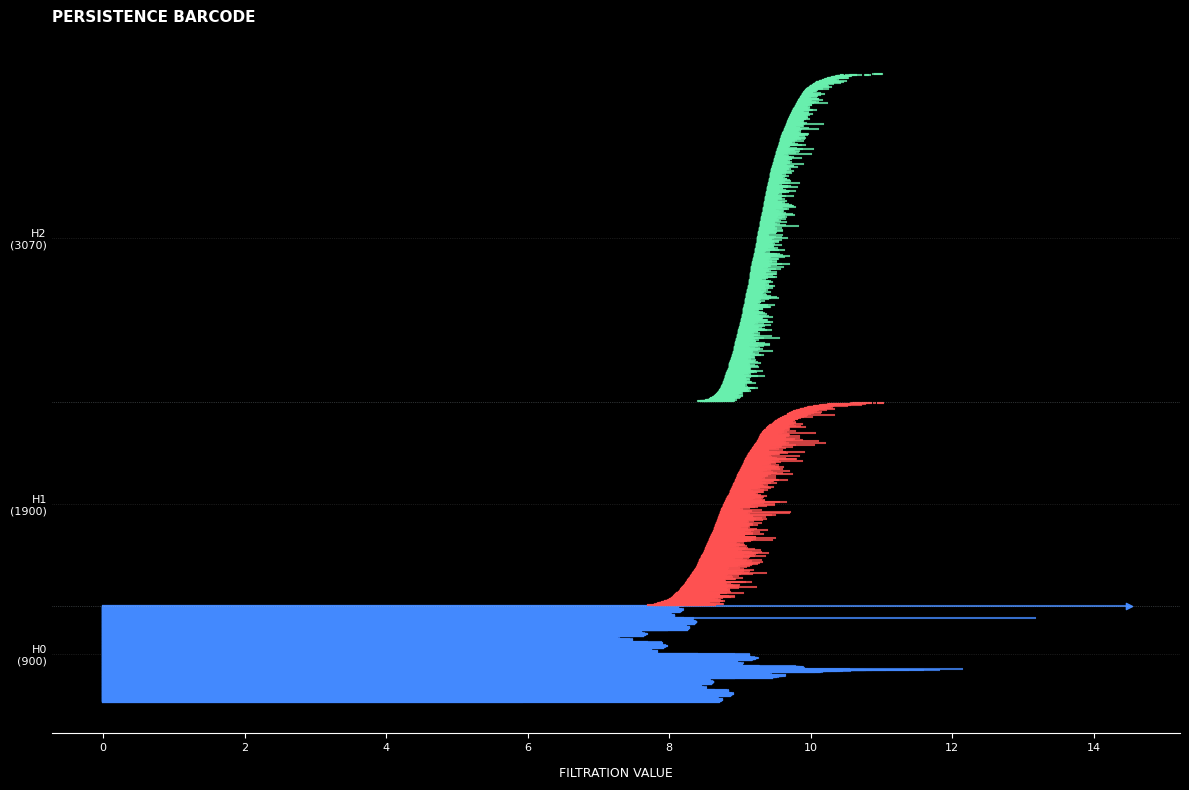

In [6]:
# --- 4.1 Persistence Barcode ---
# Visualize the topological features as a barcode (Lifetimes of features)

def plot_barcode_architectural(diagrams):
    fig, ax = plt.subplots(figsize=(12, 8))
    fig.patch.set_facecolor(viz_style.BLACK)
    ax.set_facecolor(viz_style.BLACK)
    
    # Colors for H0, H1, H2
    colors = [viz_style.BLUE, viz_style.RED, viz_style.GREEN]
    labels = ["H0", "H1", "H2"]
    
    # Determine global max death for plotting infinite bars
    finite_vals = [pt for dgm in diagrams for pt in dgm.flatten() if np.isfinite(pt)]
    max_val = np.max(finite_vals) if finite_vals else 1.0
    plot_limit = max_val * 1.1
    
    current_y = 0
    ytick_locs = []
    ytick_labels = []
    
    # Iterate through dimensions (H0, H1, H2)
    for i, dgm in enumerate(diagrams):
        if len(dgm) == 0: continue
        
        # Handle infinity
        dgm_plot = dgm.copy()
        inf_mask = np.isinf(dgm_plot[:, 1])
        dgm_plot[inf_mask, 1] = plot_limit
        
        # Sort by birth time
        sort_idx = np.argsort(dgm_plot[:, 0])
        dgm_sorted = dgm_plot[sort_idx]
        
        n_bars = len(dgm_sorted)
        color = colors[i] if i < len(colors) else viz_style.WHITE
        
        for j in range(n_bars):
            birth, death = dgm_sorted[j]
            y = current_y + j
            
            # Draw bar
            ax.plot([birth, death], [y, y], color=color, linewidth=1.5, alpha=0.8)
            
            # If it was infinite, draw an arrow or marker at the end
            if inf_mask[sort_idx][j]:
                ax.scatter(death, y, color=color, marker='>', s=20)
        
        # Label position
        ytick_locs.append(current_y + n_bars/2)
        ytick_labels.append(f"{labels[i] if i < len(labels) else f'H{i}'}\n({n_bars})")
        
        # Add separator line
        if i < len(diagrams) - 1:
            sep_y = current_y + n_bars + 5
            ax.axhline(sep_y, color=viz_style.GRAY, linestyle=':', linewidth=0.5, alpha=0.5)
            current_y = sep_y + 5
        else:
            current_y += n_bars

    # Formatting
    ax.set_yticks(ytick_locs)
    ax.set_yticklabels(ytick_labels, color=viz_style.WHITE)
    ax.tick_params(axis='y', length=0) # Hide tick marks
    
    viz_style.format_axis(ax, title="PERSISTENCE BARCODE", xlabel="FILTRATION VALUE")
    
    # Remove left spine
    ax.spines['left'].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# Check if 'diagrams' exists before plotting
if 'diagrams' in globals():
    plot_barcode_architectural(diagrams)
elif 'result' in globals() and 'dgms' in result:
    plot_barcode_architectural(result['dgms'])
else:
    print("⚠️ 'diagrams' variable not found.")
    print("Please run the previous cell (Step 4: Topological Data Analysis) to calculate persistence diagrams first.")

Architectural plot style applied (Dark Mode).


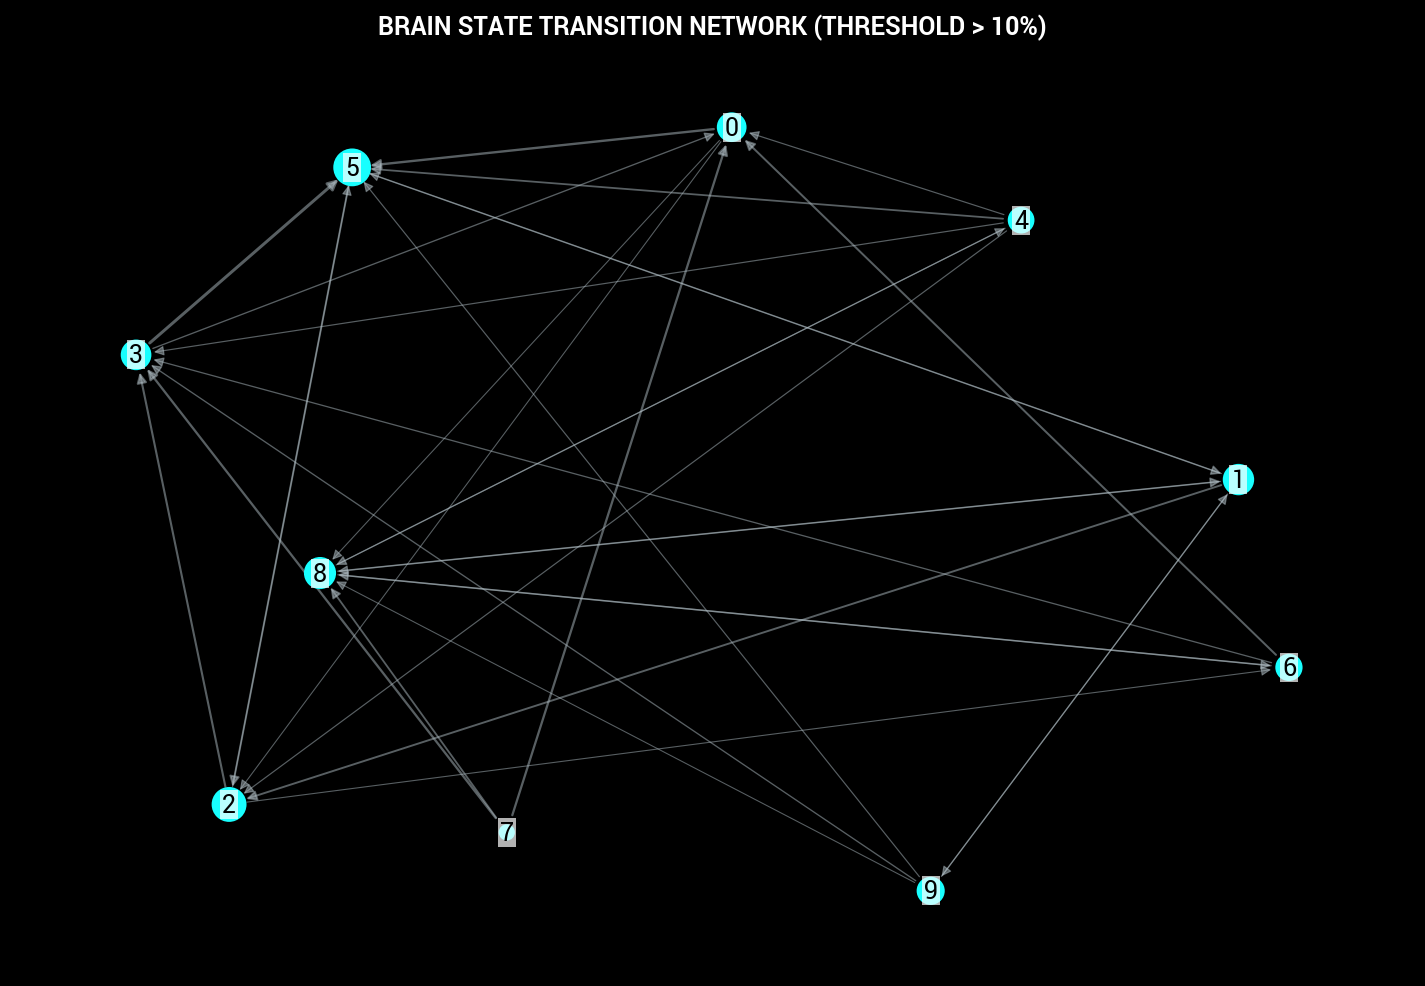

In [7]:
# --- 5. Cluster Transition Analysis ---
# Cluster the neural states
n_states = 10
kmeans = KMeans(n_clusters=n_states, random_state=42, n_init=10)
state_labels = kmeans.fit_predict(X_pca)

# Calculate Transitions
transition_matrix = np.zeros((n_states, n_states))
for t in range(len(state_labels) - 1):
    current_state = state_labels[t]
    next_state = state_labels[t+1]
    transition_matrix[current_state, next_state] += 1

# Normalize to probabilities
row_sums = transition_matrix.sum(axis=1)
transition_probs = np.divide(transition_matrix, row_sums[:, np.newaxis], out=np.zeros_like(transition_matrix), where=row_sums[:, np.newaxis]!=0)

# Visualize Network
G = nx.DiGraph()
for i in range(n_states):
    count = np.sum(state_labels == i)
    G.add_node(i, size=count)

threshold = 0.1
for i in range(n_states):
    for j in range(n_states):
        if i != j and transition_probs[i, j] > threshold:
            G.add_edge(i, j, weight=transition_probs[i, j])

viz_style.set_architectural_style() # Force style
fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor(viz_style.BLACK) # Force black background
ax.set_facecolor(viz_style.BLACK)

pos = nx.spring_layout(G, k=1.5, seed=42)
node_sizes = [G.nodes[i]['size'] * 2 for i in G.nodes]
edges = G.edges()
weights = [G[u][v]['weight'] * 5 for u, v in edges]

viz_style.plot_network_graph(
    ax, G, pos, 
    node_colors=viz_style.CYAN, 
    node_size=node_sizes,
    edge_width=weights,
    with_labels=True,
    label_font_size=12,
    title=f"BRAIN STATE TRANSITION NETWORK (THRESHOLD > {threshold*100:.0f}%)"
)

plt.show()

Cluster 0 size for PH: (88, 3)
Architectural plot style applied (Dark Mode).


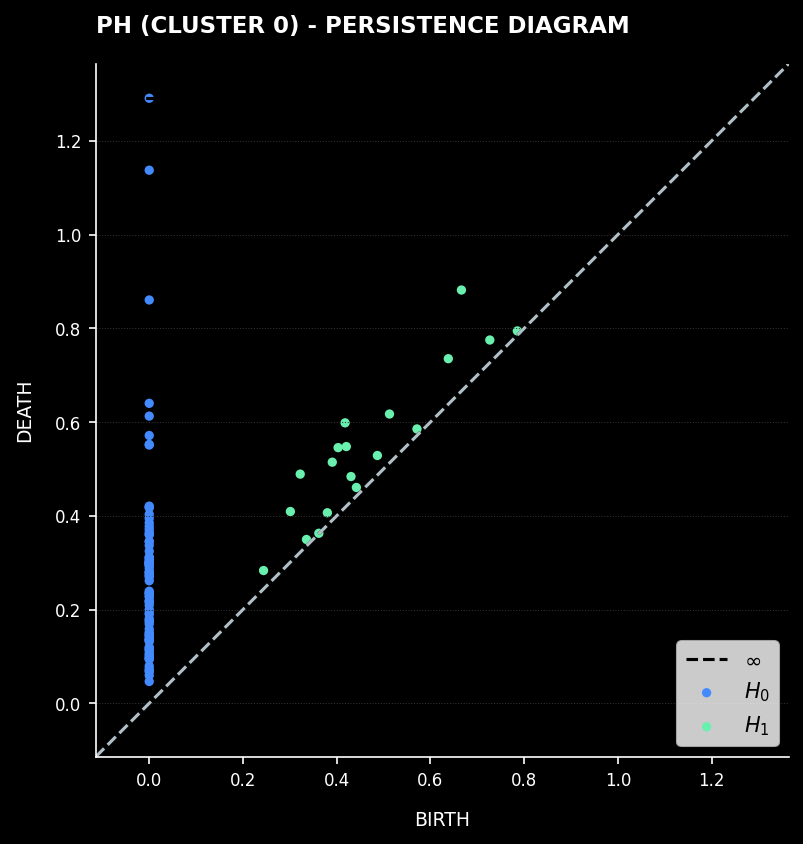

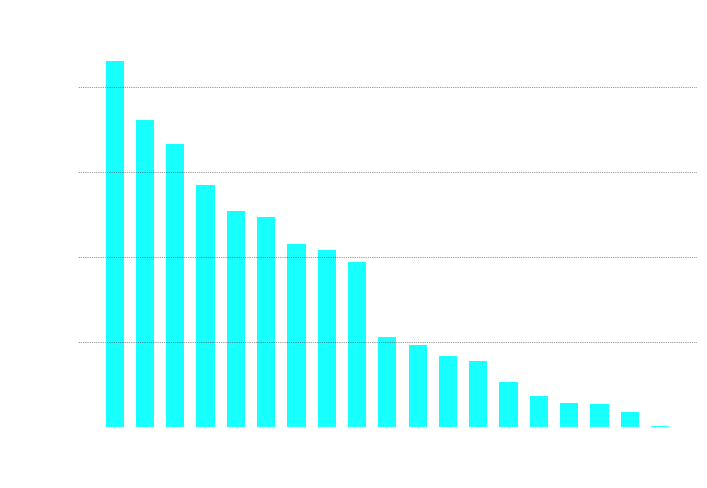

=== Persistent Homology Summary (Cluster 0) ===
Total H1 loops: 19
Significant H1 loops (>0.170): 2
Top significant loops:
 birth=0.666, death=0.882, life=0.216
 birth=0.418, death=0.598, life=0.180


In [8]:
# %%
# 1) 클러스터 0 데이터 추출 (새 변수 사용)
import numpy as np

cluster_id_ph = 0
mask_ph_c0 = (state_labels == cluster_id_ph) # Fixed variable name from cluster_labels to state_labels
X_ph_c0 = embedding_3d[mask_ph_c0]   # Fixed variable name from X_umap to embedding_3d

print("Cluster 0 size for PH:", X_ph_c0.shape)

# %%
# 2) Ripser로 PH 계산 (H0/H1)
from ripser import ripser
from persim import plot_diagrams

ph_result_c0 = ripser(X_ph_c0, maxdim=1)
dgm0_c0, dgm1_c0 = ph_result_c0["dgms"]

# %%
# 3) Persistence Diagram & Barcode 플롯
import matplotlib.pyplot as plt

# Ensure style is applied
viz_style.set_architectural_style()

fig, ax = plt.subplots(figsize=(6, 6))
plot_diagrams([dgm0_c0, dgm1_c0], show=False, ax=ax)
viz_style.format_axis(ax, title="PH (Cluster 0) - Persistence Diagram", xlabel="Birth", ylabel="Death")
ax.plot([0, 1], [0, 1], transform=ax.transAxes, color=viz_style.GRAY, linestyle="--")
plt.show()

# %%
# 4) H1 lifetime 계산 + histogram 플롯
lifetimes_c0 = dgm1_c0[:, 1] - dgm1_c0[:, 0]
lifetimes_c0 = lifetimes_c0[lifetimes_c0 > 0]  # 0 이하 제거 (안정성)

fig, ax = plt.subplots(figsize=(8, 5))
viz_style.plot_bar(ax, range(len(lifetimes_c0)), sorted(lifetimes_c0, reverse=True), 
                   color=viz_style.CYAN, title="H1 Lifetime Distribution (Cluster 0)", 
                   xlabel="Loop Index", ylabel="Lifetime")
plt.show()

# %%
# 5) Significant H1 loops 자동 검출
threshold_c0 = np.quantile(lifetimes_c0, 0.90)  # 상위 10%
sig_mask_c0 = lifetimes_c0 >= threshold_c0
sig_lifetimes_c0 = lifetimes_c0[sig_mask_c0]

# significant loops 정보 추출
dgm1_sig_c0 = dgm1_c0[sig_mask_c0]

print("=== Persistent Homology Summary (Cluster 0) ===")
print("Total H1 loops:", len(dgm1_c0))
print(f"Significant H1 loops (>{threshold_c0:.3f}):", len(dgm1_sig_c0))
print("Top significant loops:")
for b, d in dgm1_sig_c0[:10]:
    print(f" birth={b:.3f}, death={d:.3f}, life={d-b:.3f}")

Graph is connected. Nodes: 88
Architectural plot style applied (Dark Mode).
Coloring nodes by Frame index.


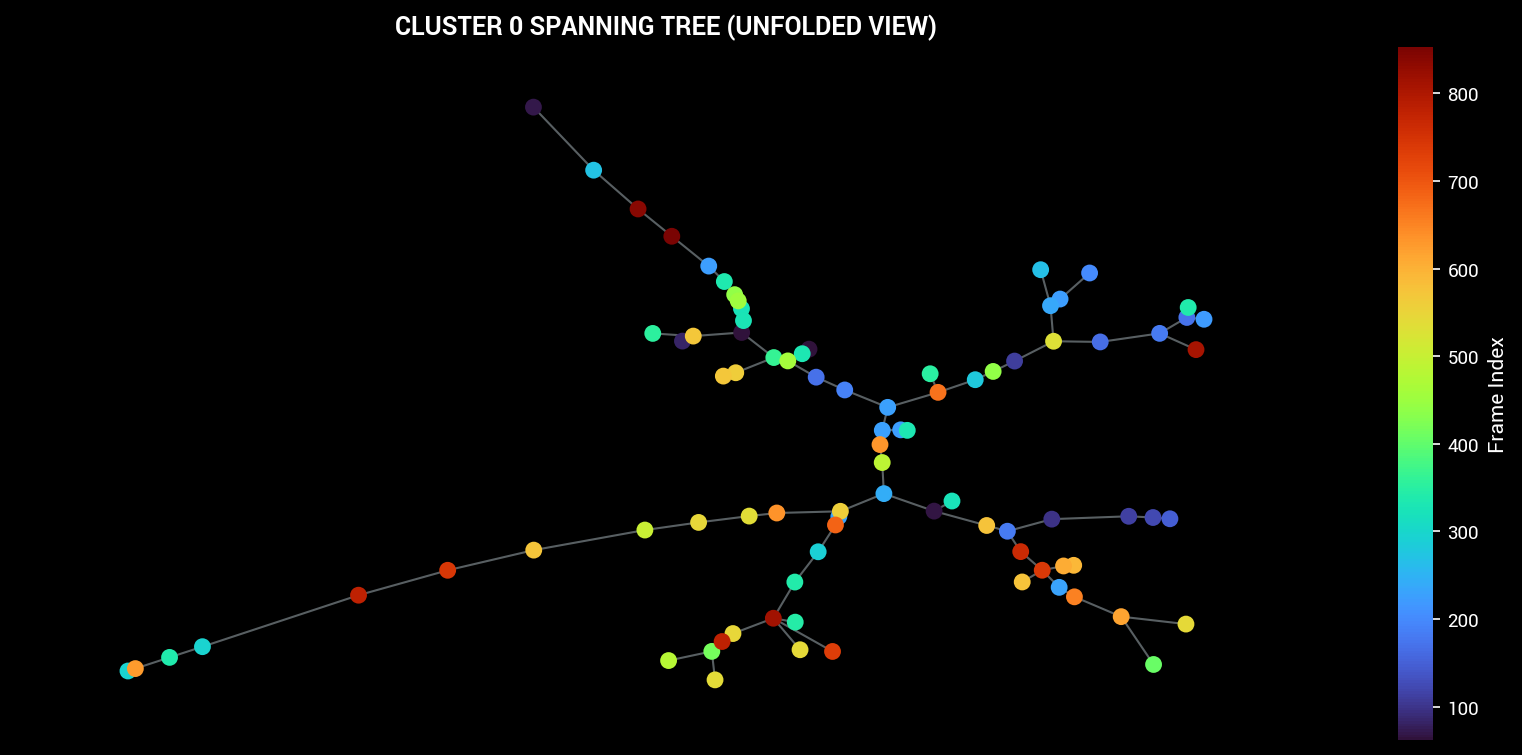

In [9]:
# %%
# 1) G에서 spanning tree 만들기 (사이클 제거)
import networkx as nx
from sklearn.neighbors import NearestNeighbors

# Need to rebuild G for Cluster 0 first since it wasn't defined in previous cell
k = 10
nbrs = NearestNeighbors(n_neighbors=k + 1).fit(X_ph_c0)
dists, inds = nbrs.kneighbors(X_ph_c0)

G_c0 = nx.Graph()
num_nodes = X_ph_c0.shape[0]
G_c0.add_nodes_from(range(num_nodes))

for i in range(num_nodes):
    for d, j in zip(dists[i][1:], inds[i][1:]):
        G_c0.add_edge(i, j, weight=float(d))

# spanning tree (최소 신장 트리)
T_full = nx.minimum_spanning_tree(G_c0, weight="weight")

# 연결된 컴포넌트 중 가장 큰 것만 선택
if not nx.is_connected(T_full):
    largest_cc = max(nx.connected_components(T_full), key=len)
    T = T_full.subgraph(largest_cc).copy()
    print(f"Graph was disconnected. Using largest component: {T.number_of_nodes()} nodes.")
else:
    T = T_full
    print("Graph is connected. Nodes:", T.number_of_nodes())

# %%
# 2) 관계 중심의 그래프 시각화 (Unfolded/Long View) + Frame Color
import matplotlib.pyplot as plt

# Ensure style is applied
viz_style.set_architectural_style()

# Frame 정보 가져오기
if 'average_response_matrix' in locals() and 'mask_ph_c0' in locals():
    all_frames = average_response_matrix.index.values
    frames_c0 = all_frames[mask_ph_c0]
    
    nodelist = list(T.nodes())
    node_colors = [frames_c0[n] for n in nodelist]
    print("Coloring nodes by Frame index.")
    use_color = True
else:
    nodelist = list(T.nodes())
    node_colors = "skyblue"
    print("Frame info not found. Using default color.")
    use_color = False

# 길게 나타내기 위해 가로가 긴 figure 설정
fig = plt.figure(figsize=(14, 6))
fig.patch.set_facecolor(viz_style.BLACK) # Force black background

# Kamada-Kawai Layout: 그래프를 "구부리지 않고" 구조대로 펼치는 데 유리함
try:
    # scale을 키워서 더 넓게 퍼지도록 함
    pos_rel = nx.kamada_kawai_layout(T, scale=2.0)
except:
    print("Kamada-Kawai layout failed/missing. Using Spring layout.")
    pos_rel = nx.spring_layout(T, k=0.15, iterations=100, seed=42)

# 엣지 그리기
nx.draw_networkx_edges(T, pos_rel, edge_color=viz_style.GRAY, alpha=0.5, width=1.0)

# 노드 그리기 (Frame 색상 적용)
if use_color:
    nodes = nx.draw_networkx_nodes(T, pos_rel, nodelist=nodelist, 
                                   node_size=50, 
                                   node_color=node_colors, 
                                   cmap='turbo', 
                                   label="Nodes")
    cbar = plt.colorbar(nodes, label="Frame Index")
    cbar.ax.yaxis.label.set_color(viz_style.WHITE)
    cbar.ax.tick_params(colors=viz_style.WHITE)
    cbar.outline.set_visible(False)
else:
    nx.draw_networkx_nodes(T, pos_rel, nodelist=nodelist, 
                           node_size=50, 
                           node_color=viz_style.CYAN, 
                           label="Nodes")

# Branch/Leaf 노드 별도 라벨링 제거 (요청사항 반영)

plt.title("CLUSTER 0 SPANNING TREE (UNFOLDED VIEW)", color=viz_style.WHITE, fontweight='bold')
plt.axis("off")
plt.show()

Building graph for ALL frames...
Full Graph connected. Nodes: 900
Architectural plot style applied (Dark Mode).
Computing layout for full graph...
Saved Spanning Tree Nodes to ..\Dataset\Processed\750749662\spanning_tree_nodes.csv
Saved Spanning Tree Edges to ..\Dataset\Processed\750749662\spanning_tree_edges.csv


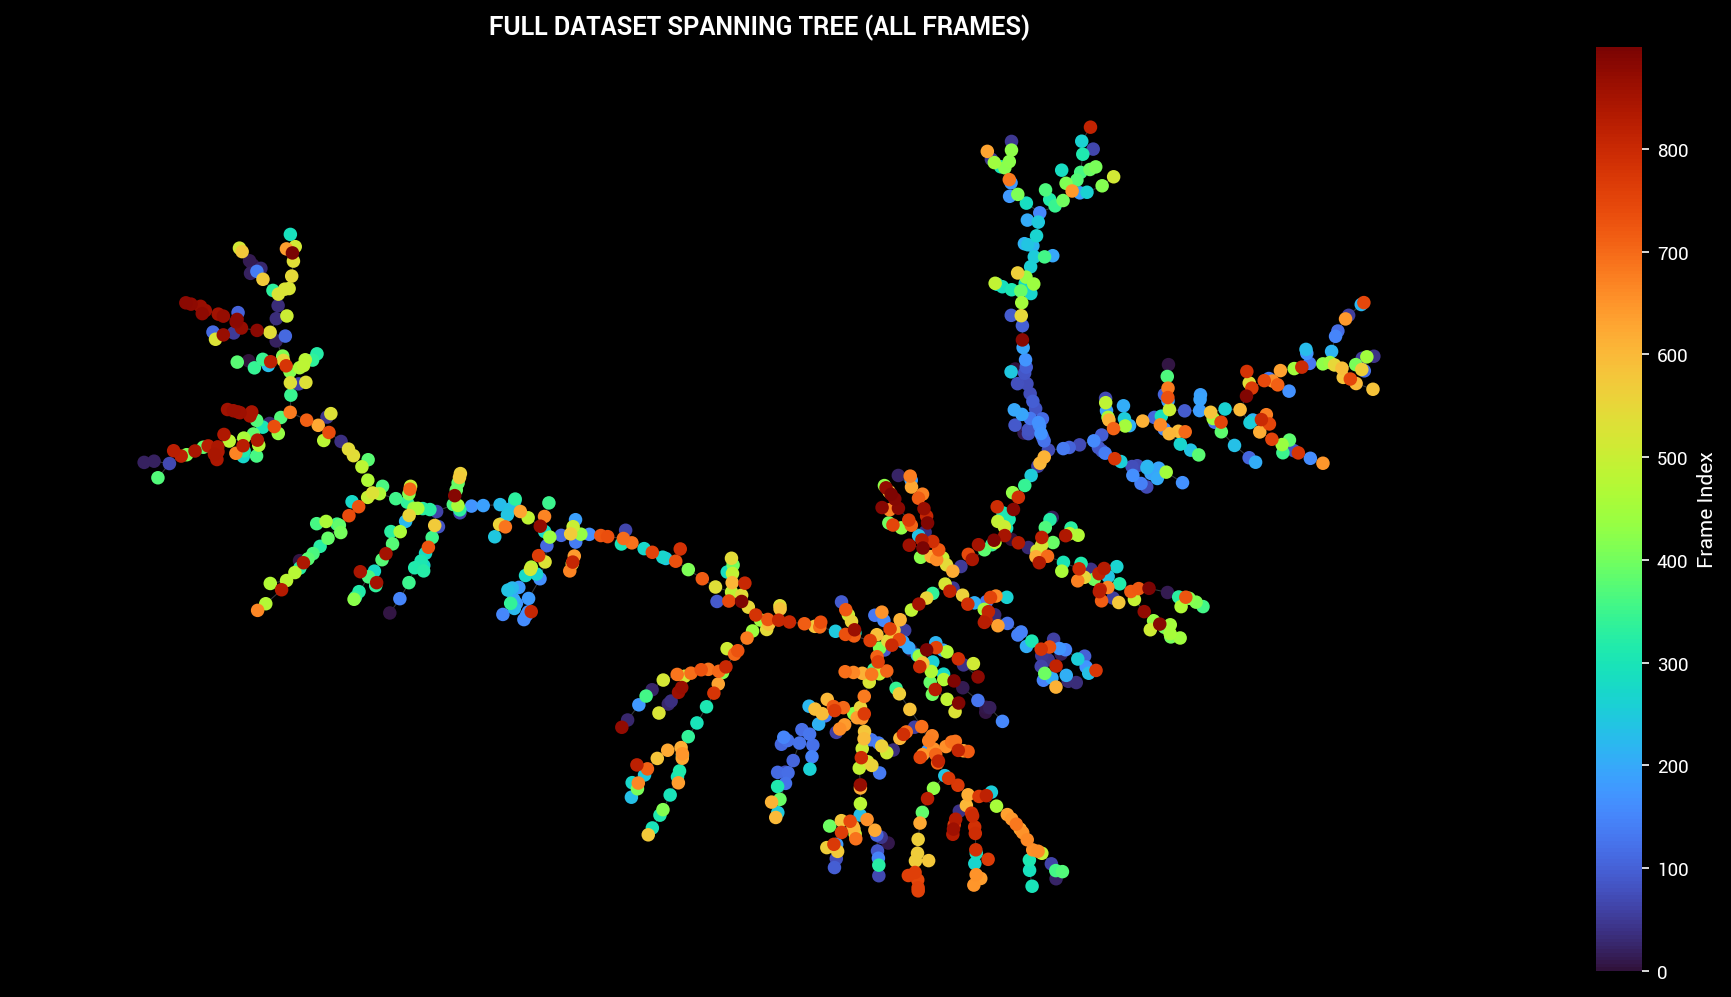

In [10]:
# %%
# 1) 전체 데이터에 대해 kNN 그래프 및 Spanning Tree 생성
print("Building graph for ALL frames...")

# 전체 데이터 사용
X_all = embedding_3d # Use embedding_3d instead of X_umap
k_all = 10

# kNN Graph 생성
nbrs_all = NearestNeighbors(n_neighbors=k_all + 1).fit(X_all)
dists_all, inds_all = nbrs_all.kneighbors(X_all)

G_all = nx.Graph()
num_all = X_all.shape[0]
G_all.add_nodes_from(range(num_all))

# Edge 추가 (Self-loop 제외)
for i in range(num_all):
    for d, j in zip(dists_all[i][1:], inds_all[i][1:]):
        G_all.add_edge(i, j, weight=float(d))

# Spanning Tree (MST)
T_all_full = nx.minimum_spanning_tree(G_all, weight="weight")

# 연결된 컴포넌트 확인
if not nx.is_connected(T_all_full):
    largest_cc_all = max(nx.connected_components(T_all_full), key=len)
    T_all = T_all_full.subgraph(largest_cc_all).copy()
    print(f"Full Graph disconnected. Using largest component: {T_all.number_of_nodes()}/{num_all} nodes.")
else:
    T_all = T_all_full
    print(f"Full Graph connected. Nodes: {T_all.number_of_nodes()}")

# %%
# 2) 전체 프레임 그래프 시각화 (Unfolded View)
viz_style.set_architectural_style() # Force style

fig, ax = plt.subplots(figsize=(16, 8))
fig.patch.set_facecolor(viz_style.BLACK) # Force black background
ax.set_facecolor(viz_style.BLACK)

# Frame 정보 (전체)
if 'average_response_matrix' in locals():
    frames_all = average_response_matrix.index.values
    # T_all에 있는 노드만 선택 (혹시 disconnected node가 빠졌을 경우 대비)
    nodelist_all = list(T_all.nodes())
    colors_all = [frames_all[n] for n in nodelist_all]
    use_color_all = True
else:
    nodelist_all = list(T_all.nodes())
    colors_all = viz_style.CYAN
    use_color_all = False

# Layout 계산 (시간이 좀 걸릴 수 있음)
print("Computing layout for full graph...")
try:
    pos_all = nx.kamada_kawai_layout(T_all, scale=2.0)
except:
    print("Kamada-Kawai failed. Using Spring layout.")
    pos_all = nx.spring_layout(T_all, k=0.1, iterations=50, seed=42)

# --- Export to CSV ---
# 1. Nodes Data
nodes_data = []
for node_id in T_all.nodes():
    x, y = pos_all[node_id]
    frame_idx = frames_all[node_id] if use_color_all else -1
    nodes_data.append({'NodeID': node_id, 'X': x, 'Y': y, 'Frame': frame_idx})

df_nodes = pd.DataFrame(nodes_data)
nodes_csv_path = Path(f"../Dataset/Processed/{session_id}/spanning_tree_nodes.csv")
df_nodes.to_csv(nodes_csv_path, index=False)
print(f"Saved Spanning Tree Nodes to {nodes_csv_path}")

# 2. Edges Data
edges_data = []
for u, v, data in T_all.edges(data=True):
    weight = data.get('weight', 1.0)
    edges_data.append({'Source': u, 'Target': v, 'Weight': weight})

df_edges = pd.DataFrame(edges_data)
edges_csv_path = Path(f"../Dataset/Processed/{session_id}/spanning_tree_edges.csv")
df_edges.to_csv(edges_csv_path, index=False)
print(f"Saved Spanning Tree Edges to {edges_csv_path}")
# ---------------------

# 그리기
nodes = viz_style.plot_network_graph(
    ax, T_all, pos_all,
    node_colors=colors_all,
    node_size=30,
    edge_width=0.5,
    edge_alpha=0.3,
    title="FULL DATASET SPANNING TREE (ALL FRAMES)"
)

if use_color_all:
    cbar = plt.colorbar(nodes, label="Frame Index", ax=ax)
    cbar.ax.yaxis.label.set_color(viz_style.WHITE)
    cbar.ax.tick_params(colors=viz_style.WHITE)
    cbar.outline.set_visible(False)

plt.show()

Labeling Branch/Leaf nodes with Frame indices...
Total Branch nodes: 213
Total Leaf nodes: 239
Architectural plot style applied (Dark Mode).


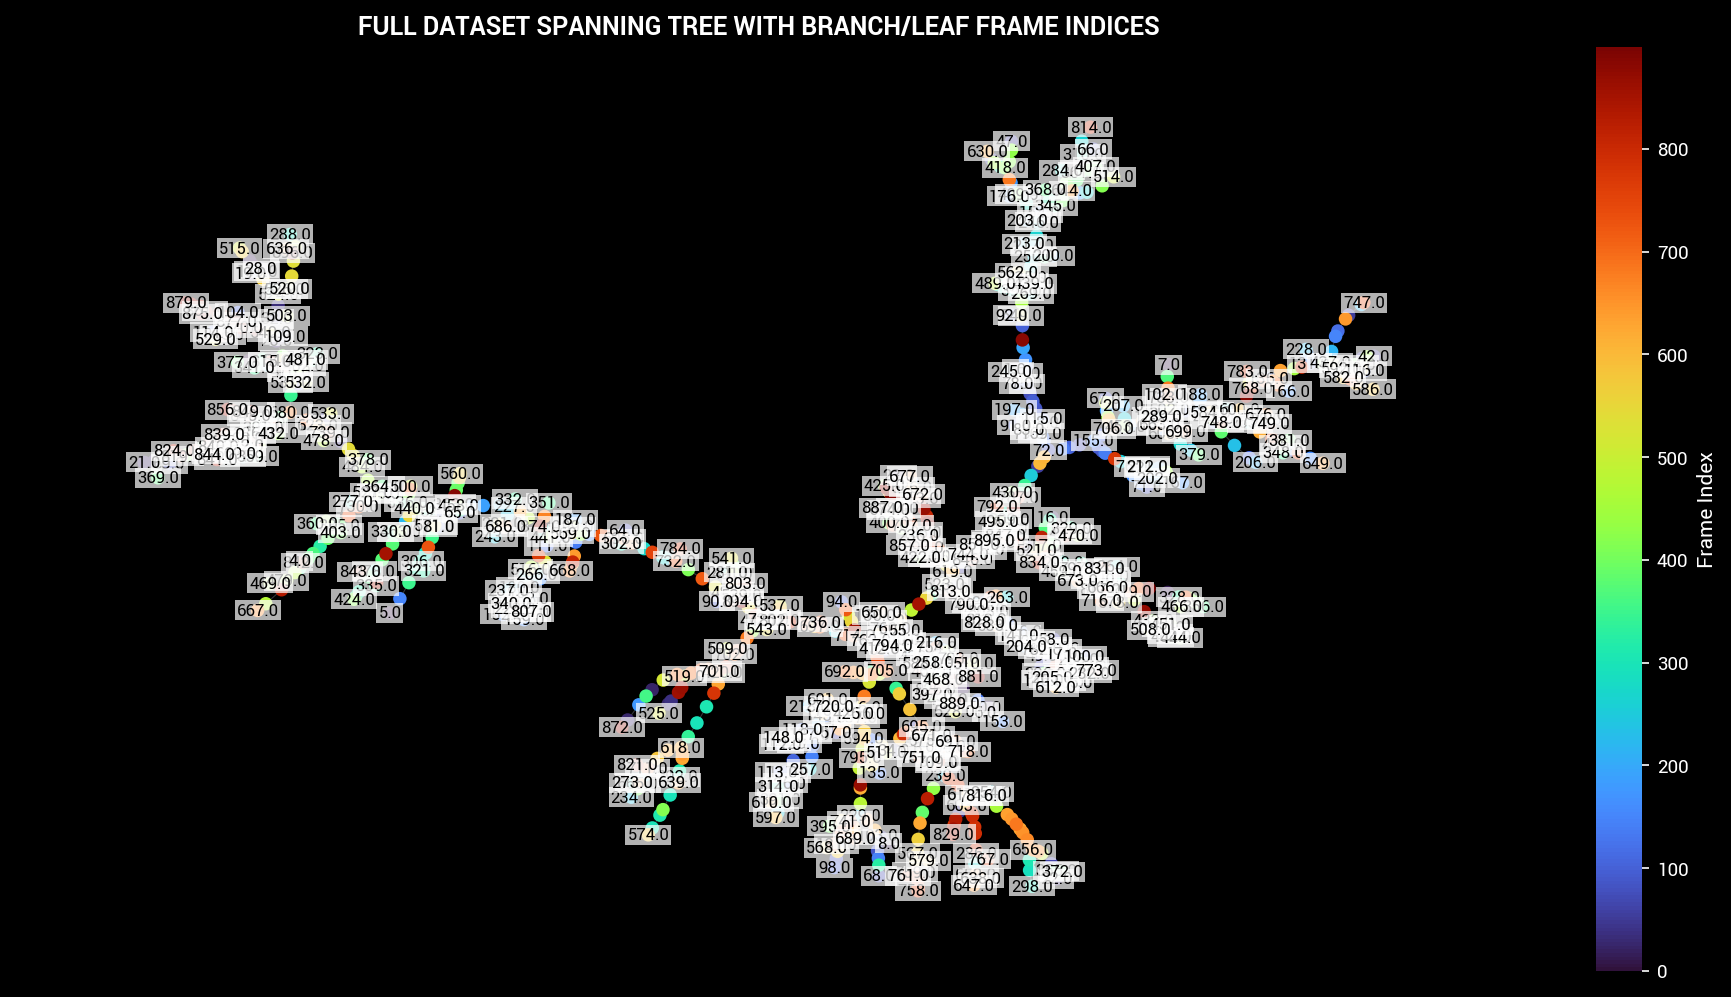

In [11]:
# %%
# 3) Branch/Leaf 노드의 Frame Index 라벨링
print("Labeling Branch/Leaf nodes with Frame indices...")

# Branch/Leaf 식별
degrees_all = dict(T_all.degree())
branch_nodes_all = [n for n, deg in degrees_all.items() if deg >= 3]
leaf_nodes_all = [n for n, deg in degrees_all.items() if deg == 1]

print(f"Total Branch nodes: {len(branch_nodes_all)}")
print(f"Total Leaf nodes: {len(leaf_nodes_all)}")

viz_style.set_architectural_style() # Force style
fig, ax = plt.subplots(figsize=(16, 8))
fig.patch.set_facecolor(viz_style.BLACK) # Force black background
ax.set_facecolor(viz_style.BLACK)

# 1. 기본 그래프 그리기 (배경)
nodes = viz_style.plot_network_graph(
    ax, T_all, pos_all,
    node_colors=colors_all if use_color_all else viz_style.CYAN,
    node_size=30,
    edge_width=0.5,
    edge_alpha=0.3,
    title="FULL DATASET SPANNING TREE WITH BRANCH/LEAF FRAME INDICES"
)

if use_color_all:
    cbar = plt.colorbar(nodes, label="Frame Index", ax=ax)
    cbar.ax.yaxis.label.set_color(viz_style.WHITE)
    cbar.ax.tick_params(colors=viz_style.WHITE)
    cbar.outline.set_visible(False)

# 2. 라벨 준비 (Branch + Leaf)
labels_to_draw = {}
# Branch nodes
for n in branch_nodes_all:
    frame_idx = frames_all[n]
    labels_to_draw[n] = str(frame_idx)

# Leaf nodes
for n in leaf_nodes_all:
    frame_idx = frames_all[n]
    labels_to_draw[n] = str(frame_idx)

# 3. 라벨 그리기
nx.draw_networkx_labels(T_all, pos_all, labels=labels_to_draw, 
                        font_size=8, font_color=viz_style.BLACK,
                        bbox=dict(facecolor=viz_style.WHITE, alpha=0.7, edgecolor='none', pad=1), ax=ax)

plt.show()

Plotting graph with image overlays (offset to reduce overlap)...
Architectural plot style applied (Dark Mode).


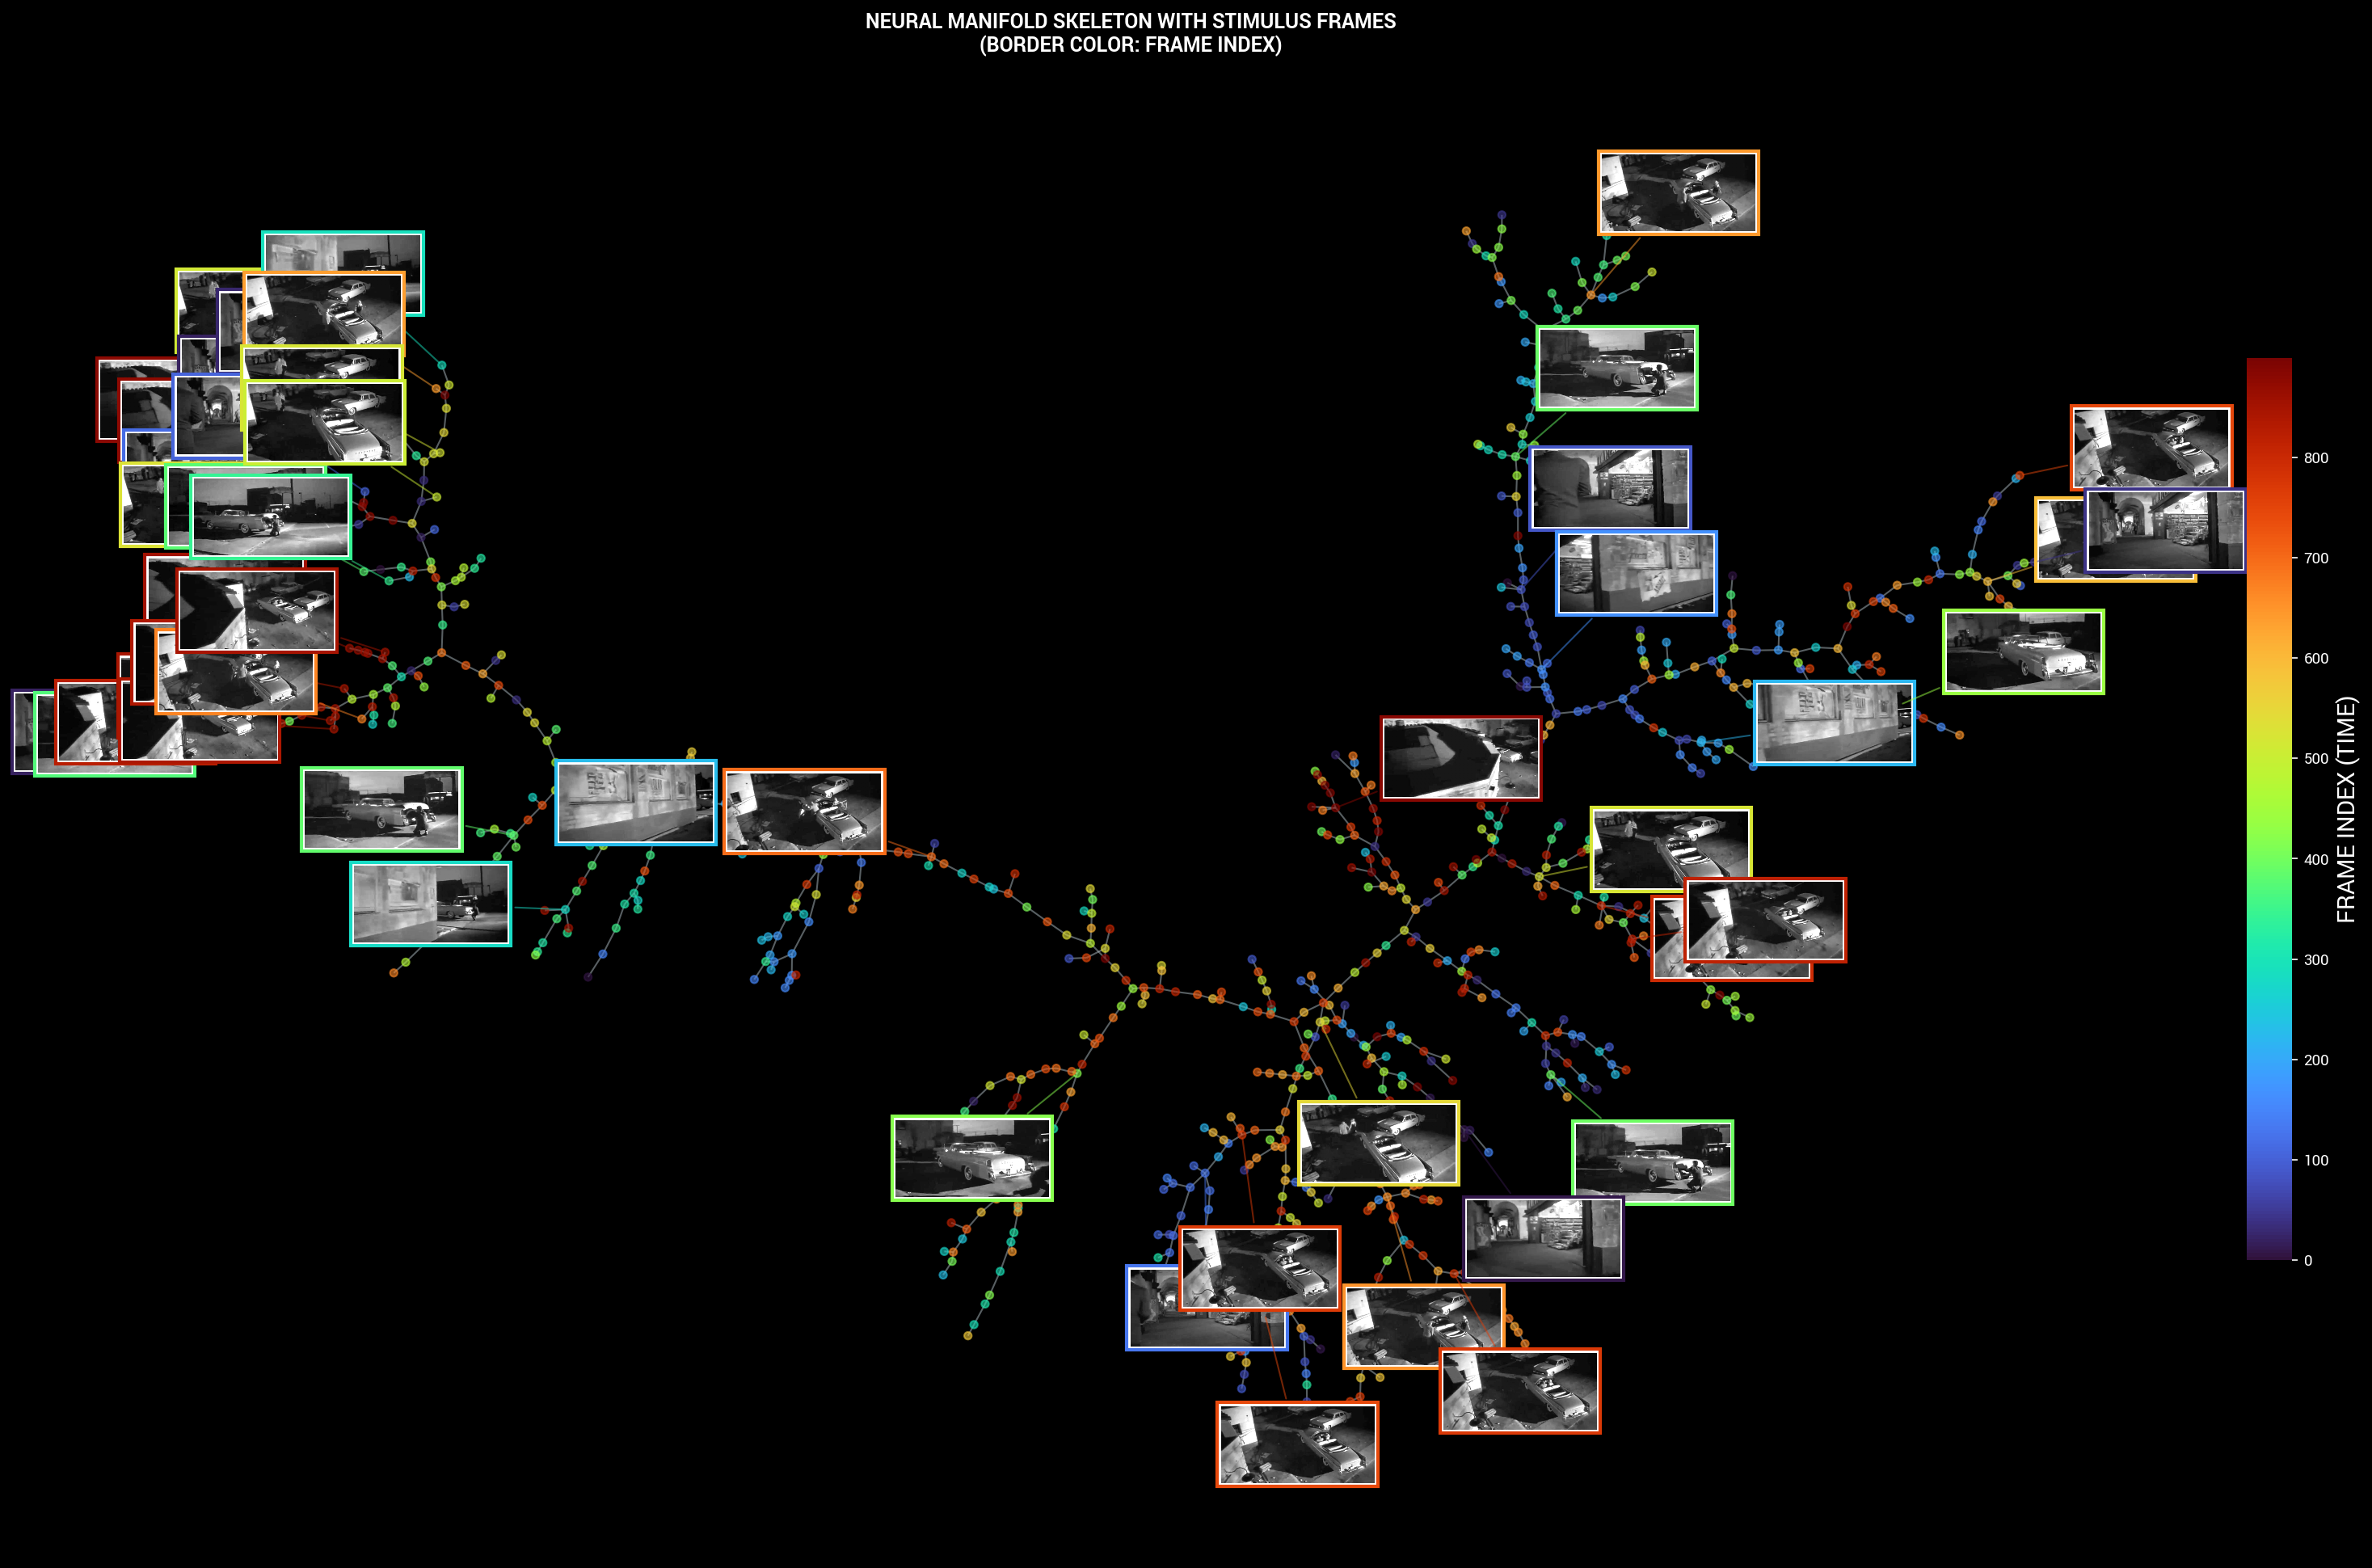

In [12]:
# %%
# 5) 그래프 위에 중요 노드(Branch/Leaf)의 프레임 이미지 오버레이
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import numpy as np

print("Plotting graph with image overlays (offset to reduce overlap)...")

viz_style.set_architectural_style() # Force style
fig, ax = plt.subplots(figsize=(24, 16))
fig.patch.set_facecolor(viz_style.BLACK) # Force black background
ax.set_facecolor(viz_style.BLACK) # Force axis background

# Use the new function in viz_style
viz_style.plot_network_with_images(
    ax, T_all, pos_all, 
    frames=frames_all, 
    movie_template=movie_template,
    branch_nodes=branch_nodes_all,
    leaf_nodes=leaf_nodes_all,
    node_colors=colors_all if use_color_all else None,
    title="NEURAL MANIFOLD SKELETON WITH STIMULUS FRAMES\n(BORDER COLOR: FRAME INDEX)"
)

# Add Colorbar for Frame Index
norm = plt.Normalize(vmin=np.min(frames_all), vmax=np.max(frames_all))
cmap = plt.cm.turbo
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.02, pad=0.01)
cbar.set_label("FRAME INDEX (TIME)", fontsize=14, color=viz_style.WHITE)
cbar.ax.yaxis.label.set_color(viz_style.WHITE)
cbar.ax.tick_params(colors=viz_style.WHITE)
cbar.outline.set_visible(False)

plt.show()